In [8]:
%load_ext autoreload
%autoreload 2
    
import datetime
import os
import ee
import geemap
import joblib
import matplotlib.pyplot as plt

from identify_locations import identify_forests, identify_route_buffer
from read_and_process_hls import compute_hls_indices
from fit_greendown_curves import compute_transition_dates, compute_average_transition_dates
from filter_ci_widths import count_narrow_ci_pixel_years
from build_data_table import build_feature_table, export_prediction_avg_assets
from edit_data_table import edit_feature_table
from plot_feature_distributions import plot_feature_distributions
from decision_trees import split_data, fit_tree, plot_decision_tree, evaluate_decision_tree
from gridmet_utils import fetch_gridmet_cdd_historical
from constants import DATA_DIR, GREENDOWN_DIR, MODEL_DIR

ee.Initialize(project='turnkey-lacing-391919')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(GREENDOWN_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

ma_forest    = identify_forests()
route_buffer = identify_route_buffer()

start_year    = 2013 #2013  # First HLS year
download_year = 2025  # Last year to download (includes 2025 for prediction)
train_year    = 2024  # Last year included in model training

refit_models = False

In [ ]:

# ----------------------------
# Fit logistic curves for each year (download all years including 2025)
# ----------------------------
all_year_paths = []
for y in range(start_year, download_year + 1):
    print(f'Processing {y}...')
    hls   = compute_hls_indices(route_buffer, ma_forest, y)
    paths = compute_transition_dates(hls, route_buffer, ma_forest, y, data_dir=DATA_DIR, greendown_dir=GREENDOWN_DIR)
    all_year_paths.append(paths)

prev_year_paths = all_year_paths[-1]   # most recent year

# ----------------------------
# Average transition dates across all years
# ----------------------------
print('Computing averages...')
avg_paths = compute_average_transition_dates(all_year_paths, data_dir=DATA_DIR, greendown_dir=GREENDOWN_DIR)

# ----------------------------
# Export committed assets the live (Action) prediction needs for
# doy_minus_avg_middle: the CI-filtered per-pixel cross-year average and the
# global gap-fill scalar. Re-run on every retrain, then commit:
#   greendown_middle_avg_filtered.tif, greendown_avg_meta.json
# ----------------------------
print('\nExporting prediction average assets...')
export_prediction_avg_assets(DATA_DIR, GREENDOWN_DIR)

# ----------------------------
# Filter: pixels with CI width < 15 days for all transitions
# ----------------------------
print('\nFiltering pixel-years by CI width...')
years = list(range(start_year, download_year + 1))
count_narrow_ci_pixel_years(GREENDOWN_DIR, years)

Prepare Data

In [2]:
# ----------------------------
# Download gridMET cold degree-days for training years (stored locally).
# Skips any year whose gridmet_cdd_{year}.npz is already cached.
# Must be run before build_feature_table so the cdd_accumulated feature
# can be populated. Re-running is safe — cached years are skipped.
# ----------------------------
print('\nDownloading gridMET CDD for training years...')
training_years = list(range(start_year, train_year + 1))
for y in training_years:
    fetch_gridmet_cdd_historical(y, route_buffer, DATA_DIR)

# ----------------------------
# Build labeled EVI/NDVI feature table (training years only: 2013–2024)
# ----------------------------
print('\nBuilding labeled feature table...')
feature_df = build_feature_table(DATA_DIR, GREENDOWN_DIR, training_years)
#plot_feature_distributions(feature_df)
feature_df_edited = edit_feature_table(feature_df, GREENDOWN_DIR, MODEL_DIR)
print(feature_df_edited.head())
print('\nNaN counts per column:')
print(feature_df_edited.isna().sum())
#plot_feature_distributions(feature_df_edited)



  gridMET CDD for 2013 already cached at ./Data/gridmet_cdd_2013.npz
  gridMET CDD for 2014 already cached at ./Data/gridmet_cdd_2014.npz
  gridMET CDD for 2015 already cached at ./Data/gridmet_cdd_2015.npz
  gridMET CDD for 2016 already cached at ./Data/gridmet_cdd_2016.npz
  gridMET CDD for 2017 already cached at ./Data/gridmet_cdd_2017.npz
  gridMET CDD for 2018 already cached at ./Data/gridmet_cdd_2018.npz
  gridMET CDD for 2019 already cached at ./Data/gridmet_cdd_2019.npz
  gridMET CDD for 2020 already cached at ./Data/gridmet_cdd_2020.npz
  gridMET CDD for 2021 already cached at ./Data/gridmet_cdd_2021.npz
  gridMET CDD for 2022 already cached at ./Data/gridmet_cdd_2022.npz
  gridMET CDD for 2023 already cached at ./Data/gridmet_cdd_2023.npz
  gridMET CDD for 2024 already cached at ./Data/gridmet_cdd_2024.npz

Building labeled feature table...
  2013: 615 qualifying pixels
  2014: 236 qualifying pixels
  2015: 405 qualifying pixels
  2016: 284 qualifying pixels
  2017: 178 qual

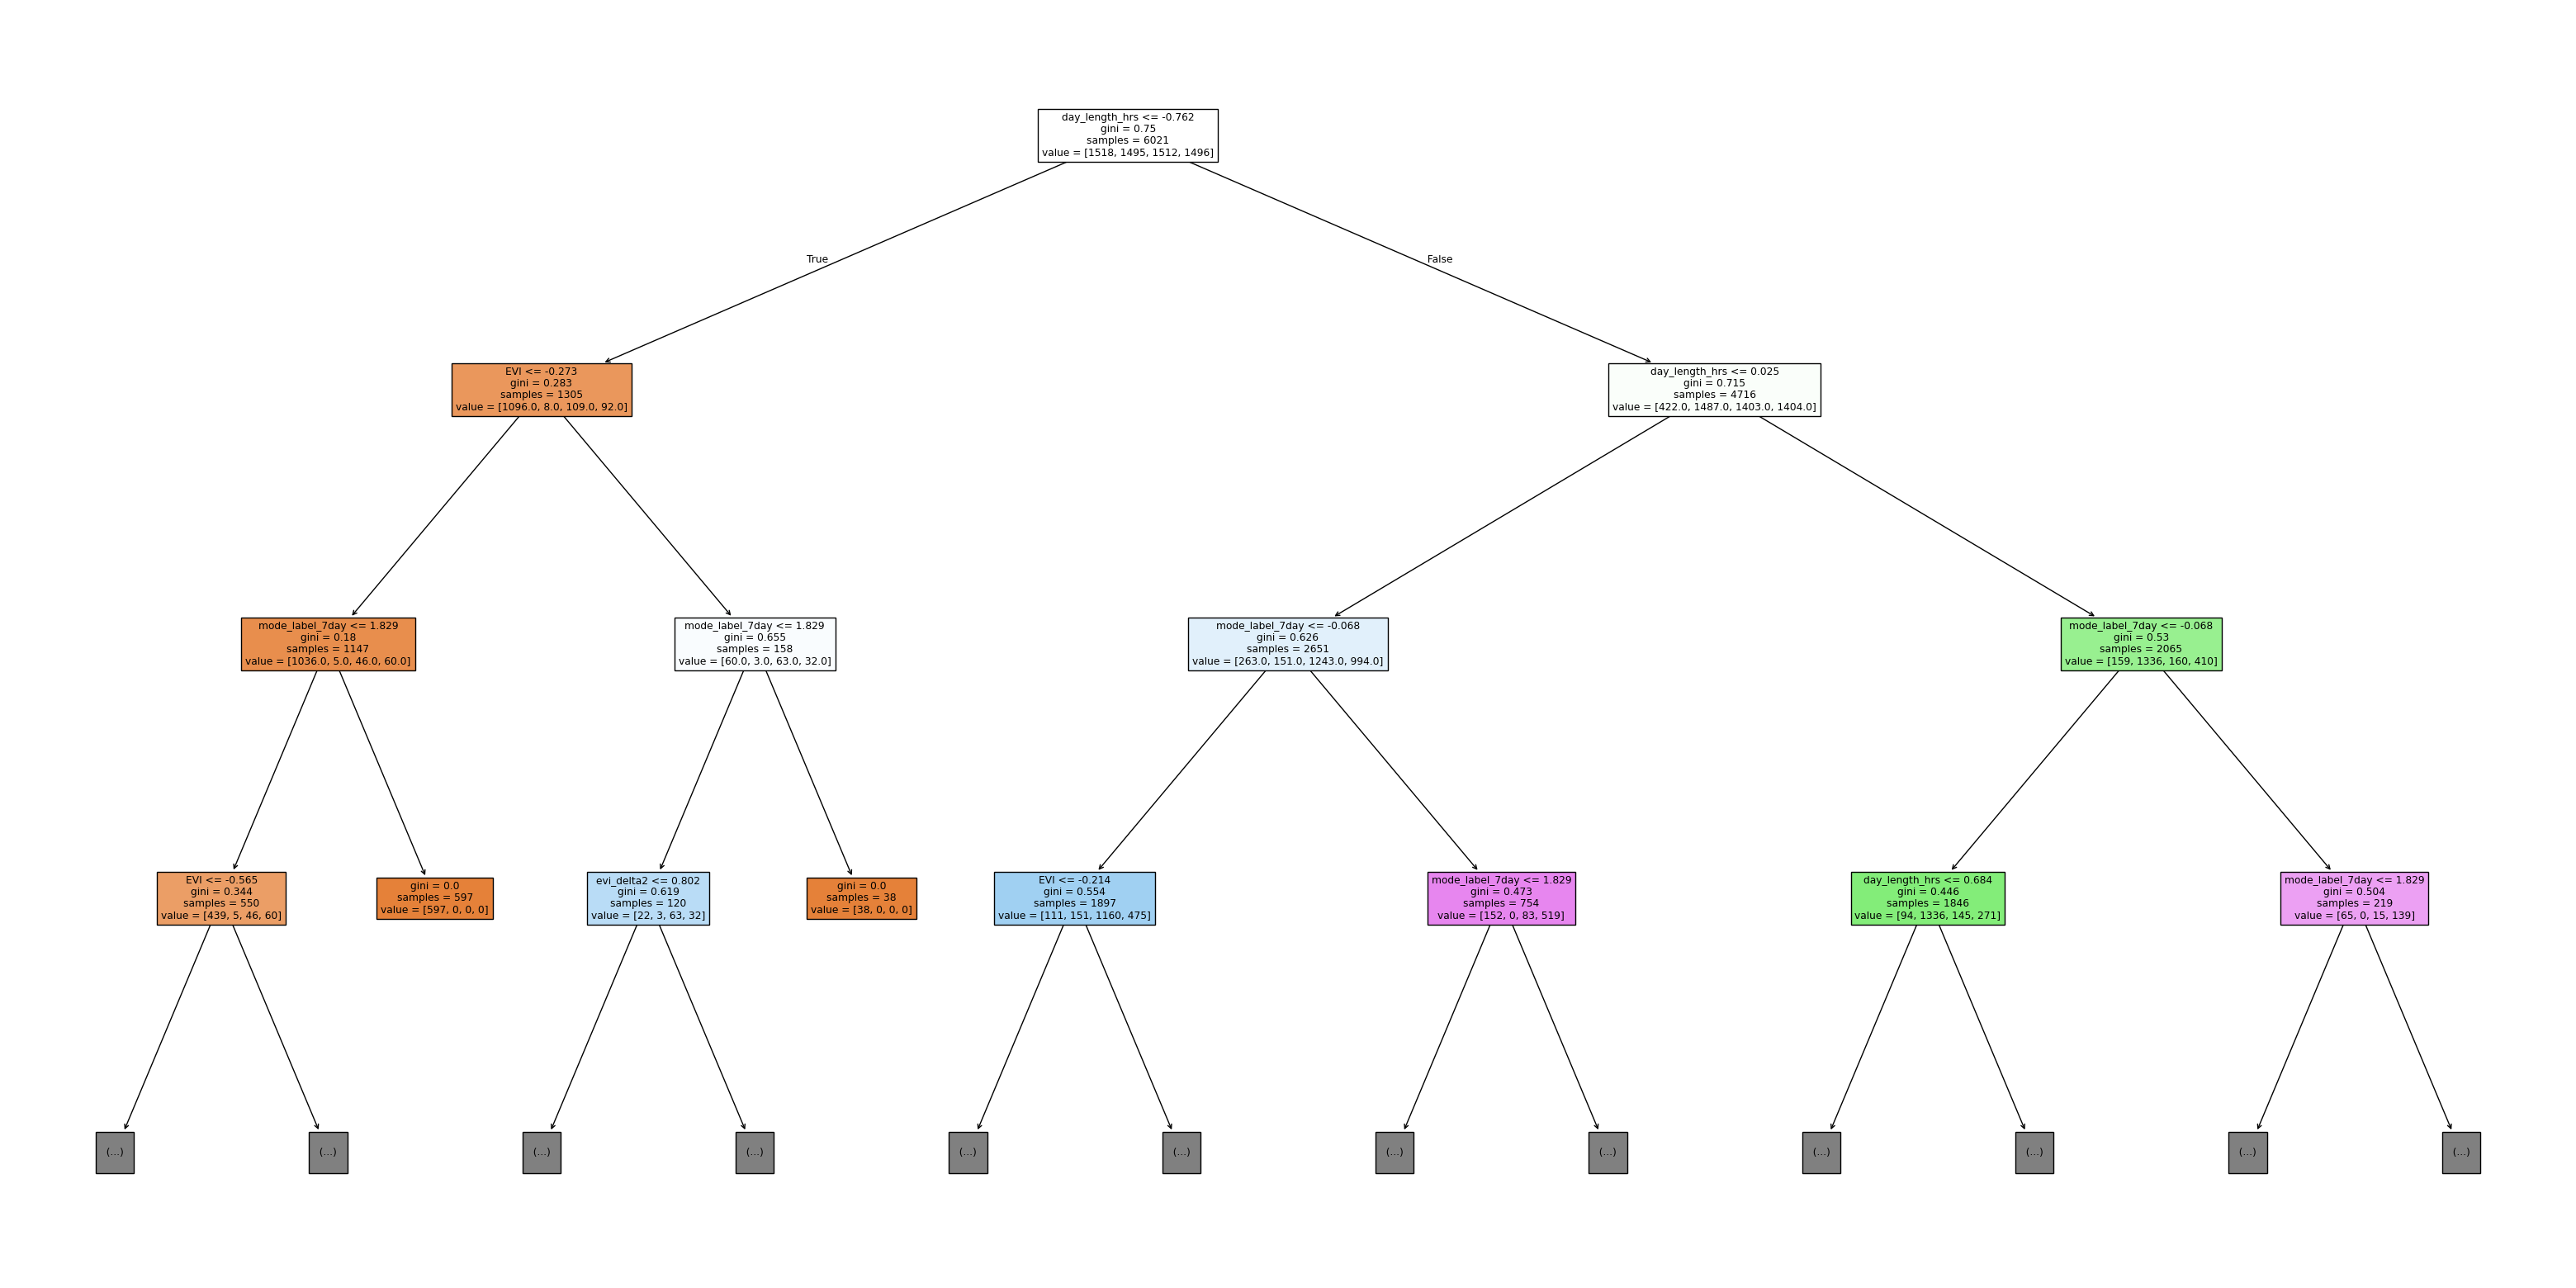

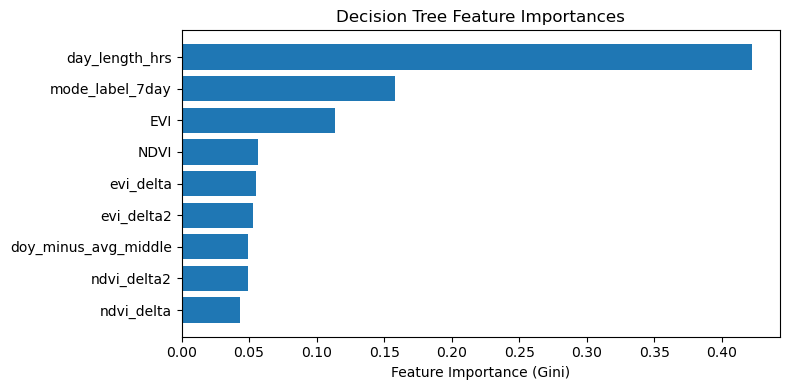


Test Accuracy Score:
0.7608370702541106
              precision    recall  f1-score   support

       after       0.86      0.86      0.86       489
      before       0.84      0.79      0.81       512
       early       0.69      0.74      0.71       495
        late       0.67      0.66      0.66       511

    accuracy                           0.76      2007
   macro avg       0.76      0.76      0.76      2007
weighted avg       0.76      0.76      0.76      2007


Train Accuracy Score:
1.0
              precision    recall  f1-score   support

       after       1.00      1.00      1.00      1518
      before       1.00      1.00      1.00      1495
       early       1.00      1.00      1.00      1512
        late       1.00      1.00      1.00      1496

    accuracy                           1.00      6021
   macro avg       1.00      1.00      1.00      6021
weighted avg       1.00      1.00      1.00      6021



In [21]:
#Decision tree no pruning
# ----------------------------
# Build decision tree
# ----------------------------
x_train, x_test, y_train, y_test = split_data(feature_df_edited)
filename = 'decision_tree_model_no_pruning.joblib'
if refit_models or not os.path.exists(os.path.join(MODEL_DIR, filename)):
    mdl = fit_tree(x_train, y_train, False)

    # Save model for dashboard use
    joblib.dump(mdl, os.path.join(MODEL_DIR, filename))
    joblib.dump(mdl, os.path.join(MODEL_DIR, 'decision_tree_model.joblib')) #save as current best model
    print(f'Model saved to {MODEL_DIR}/decision_tree_model_no_pruning.joblib')
else:
    mdl = joblib.load(os.path.join(MODEL_DIR, filename))

plot_decision_tree(mdl, x_train, MODEL_DIR)

evaluate_decision_tree(mdl, x_test, y_test, x_train, y_train)

#Take-away: without pruning the accuracy on the training data is 1 and the accuracy on the testing data in 0.75 so the model is overfitting
    #With pruning the test accuracy is 0.74 and training is 0.78 so much closer and less overfitting


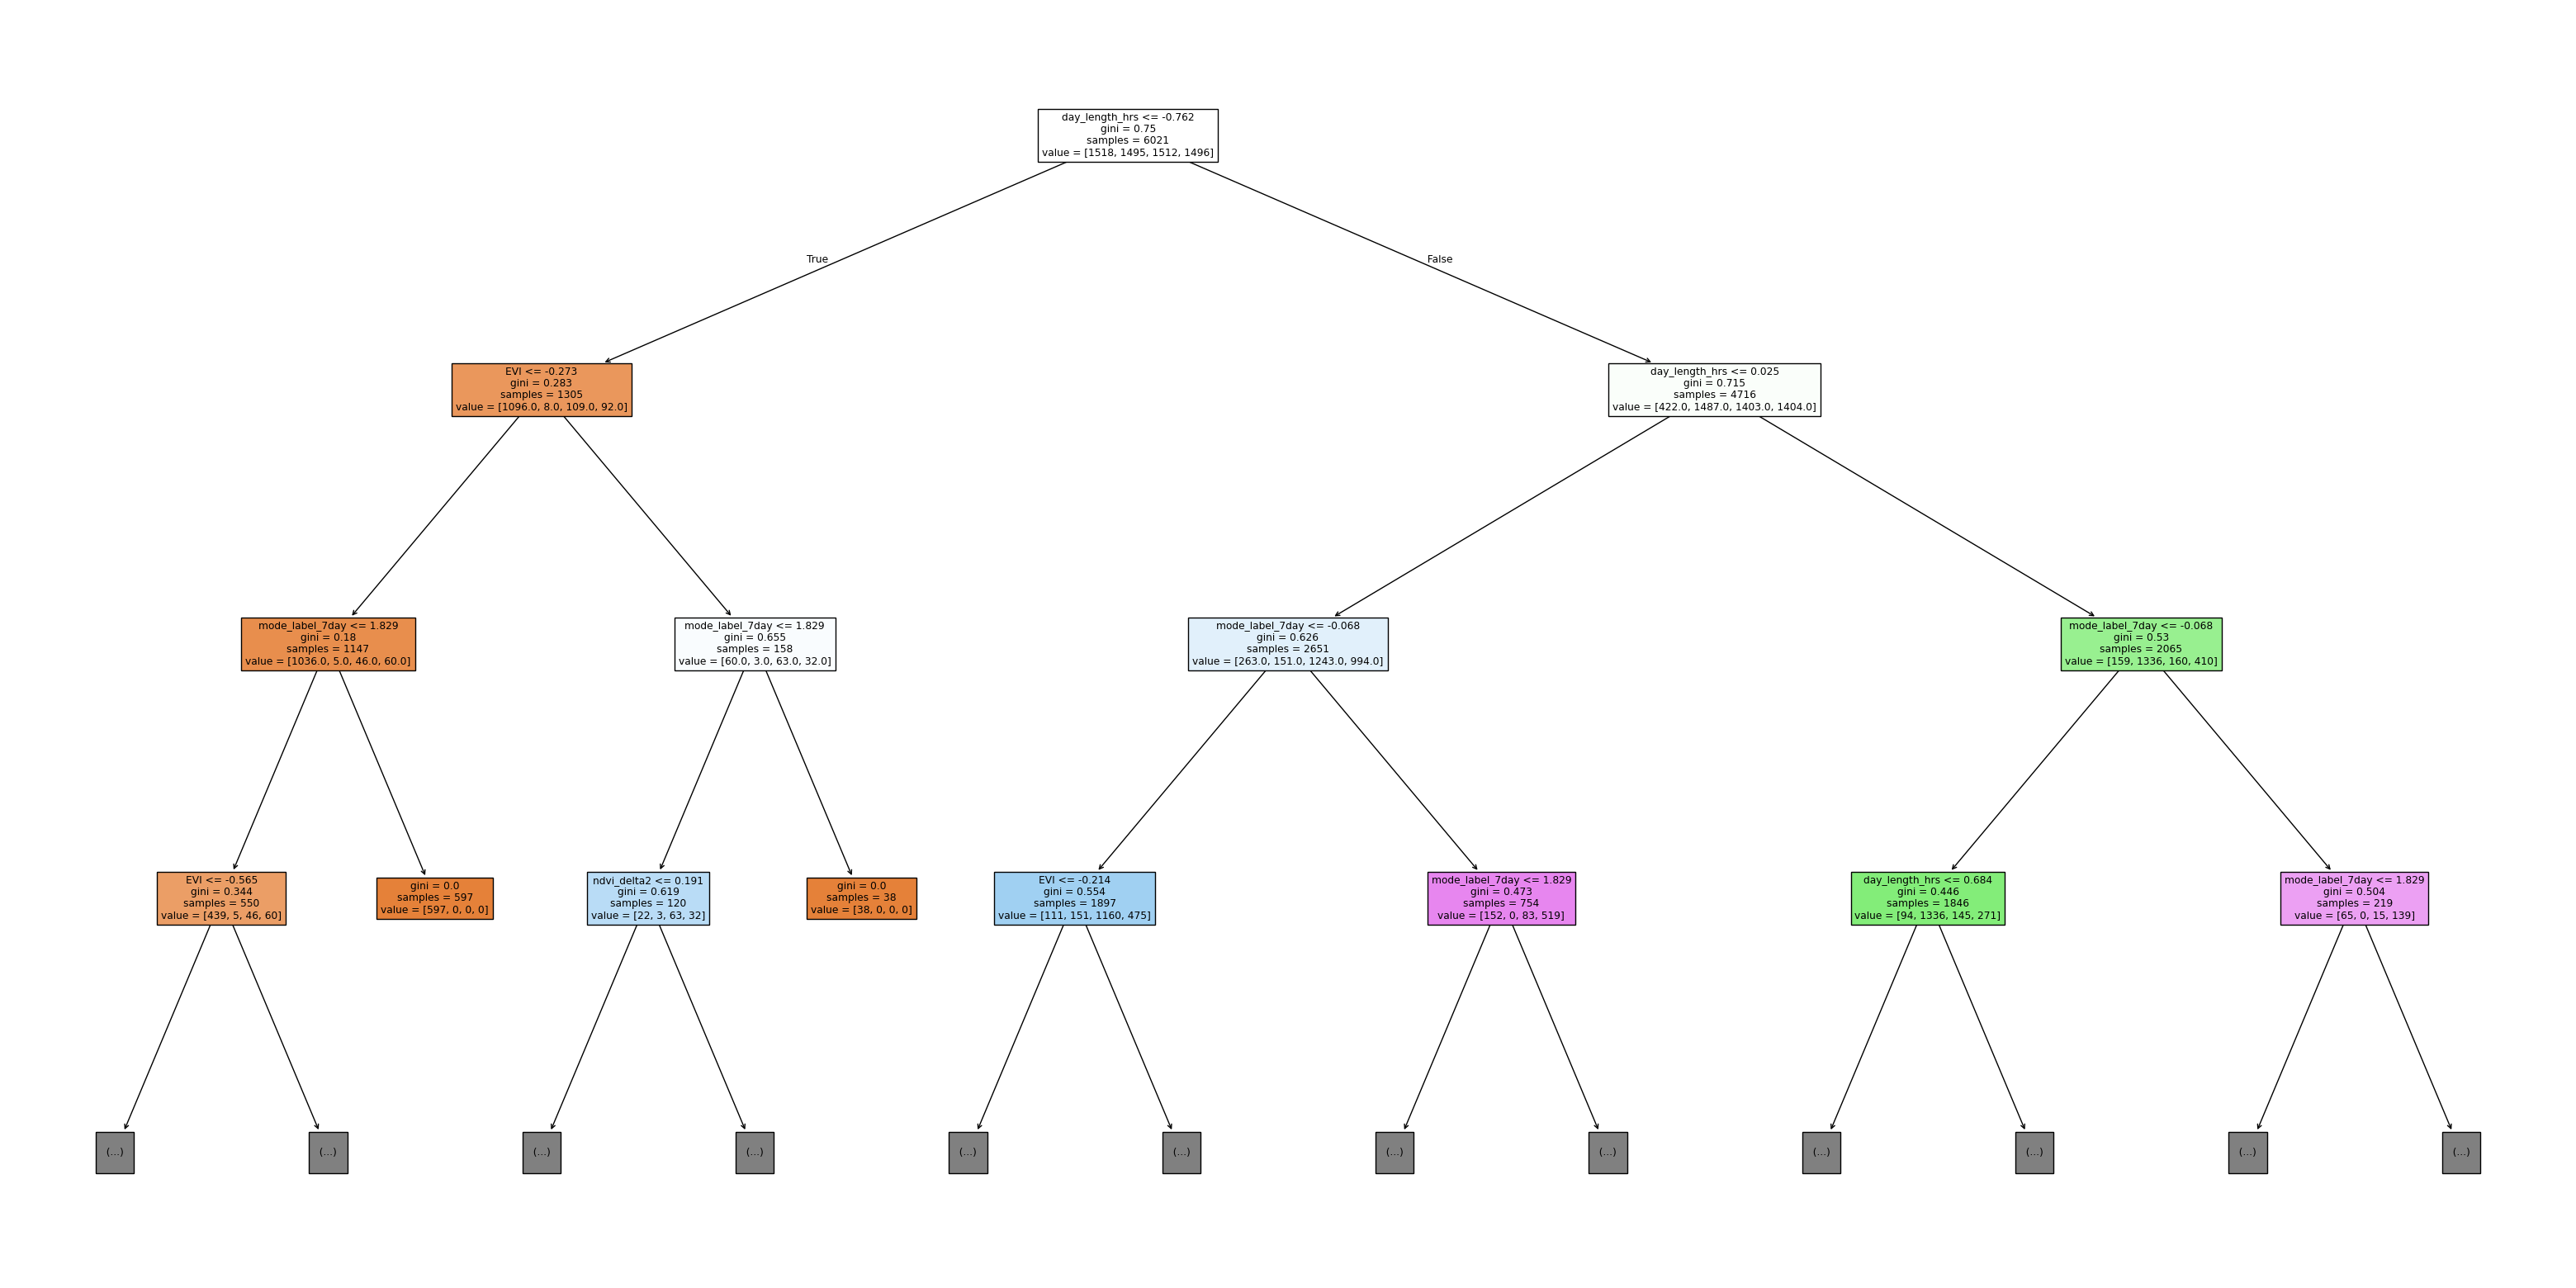

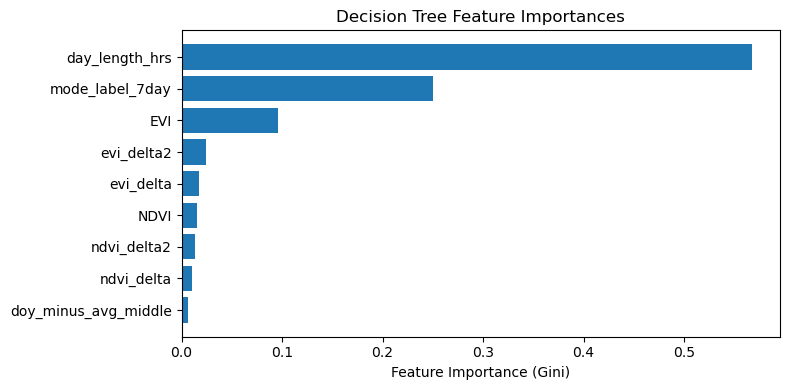


Test Accuracy Score:
0.7463876432486298
              precision    recall  f1-score   support

       after       0.86      0.85      0.85       489
      before       0.78      0.83      0.81       512
       early       0.68      0.67      0.67       495
        late       0.66      0.64      0.65       511

    accuracy                           0.75      2007
   macro avg       0.75      0.75      0.75      2007
weighted avg       0.75      0.75      0.75      2007


Train Accuracy Score:
0.7887394120577977
              precision    recall  f1-score   support

       after       0.91      0.89      0.90      1518
      before       0.78      0.89      0.83      1495
       early       0.75      0.69      0.72      1512
        late       0.71      0.68      0.69      1496

    accuracy                           0.79      6021
   macro avg       0.79      0.79      0.79      6021
weighted avg       0.79      0.79      0.79      6021



In [22]:
#Decision tree with pruning
# ----------------------------
# Build decision tree
# ----------------------------
x_train, x_test, y_train, y_test = split_data(feature_df_edited)

filename = 'decision_tree_model_pruned.joblib'
if refit_models or not os.path.exists(os.path.join(MODEL_DIR, filename)):
    mdl = fit_tree(x_train, y_train, True)

    # Save model for dashboard use
    joblib.dump(mdl, os.path.join(MODEL_DIR, filename))
    print(f'Model saved to {MODEL_DIR}/decision_tree_model_no_pruning.joblib')
    
else:
    mdl = joblib.load(os.path.join(MODEL_DIR, filename))

plot_decision_tree(mdl, x_train, MODEL_DIR)

evaluate_decision_tree(mdl, x_test, y_test, x_train, y_train)


In [ ]:
# ----------------------------
# RNN Training
# Builds a separate feature table with pixel_id and temperature features
# retained, reshapes into per-pixel-year sequences, trains an LSTM model,
# and saves rnn_model.pt + rnn_norm_stats.json + rnn_model_config.json.
# The decision tree (Cell 1) is unchanged; the website continues to use it.
# ----------------------------
import torch
import numpy as np
from rnn_model import (
    RNN_FEATURE_COLS, RNNPhenologyModel,
    build_rnn_sequences, compute_rnn_norm_stats, normalize_sequences,
    split_sequences, oversample_sequences, train_rnn, evaluate_rnn, save_rnn_model,
)

# Rebuild feature table with pixel_id retained and temperature features enabled.
# Reuses already-downloaded HLS stacks and gridMET cache — no new GEE calls.
print('Building RNN feature table (with pixel_id + temperature)...')
rnn_df = build_feature_table(DATA_DIR, GREENDOWN_DIR, training_years,
                              retain_pixel_id=True,
                              include_temperature=True)
n_pixels = rnn_df['pixel_id'].nunique()
print(f'  {len(rnn_df)} observations across {n_pixels} unique pixels')
print(f'  NaN counts:\n{rnn_df[RNN_FEATURE_COLS].isna().sum().to_string()}')

# Reshape into per-pixel-year sequences (one sequence per pixel per year)
sequences = build_rnn_sequences(rnn_df)
seq_lens  = [len(s[0]) for s in sequences]
print(f'\n  {len(sequences)} sequences  |  '
      f'length range: {min(seq_lens)}–{max(seq_lens)}  |  '
      f'median: {int(sorted(seq_lens)[len(seq_lens)//2])}')

# Compute normalization stats and normalize in-place.
# normalize_sequences replaces any remaining NaN with 0.0 (= feature mean
# in z-score space), so NaN in temperature features cannot reach the LSTM.
norm_stats = compute_rnn_norm_stats(sequences)
normalize_sequences(sequences, norm_stats)
nan_check = sum(np.isnan(f).any() for f, _ in sequences)
print(f'  Sequences with NaN after normalization: {nan_check}  (must be 0)')

# Three-way split: 70% train / 15% val / 15% test.
# Test set is held out entirely until final evaluation — val drives early stopping.
# split_sequences splits by pixel-year so no pixel leaks across splits.
trainval_seqs, test_seqs  = split_sequences(sequences,     val_frac=0.15, seed=42)
train_seqs,    val_seqs   = split_sequences(trainval_seqs, val_frac=0.176, seed=42)
# 0.176 × 85% ≈ 15% of total
print(f'  Train: {len(train_seqs)}  |  Val: {len(val_seqs)}  |  Test: {len(test_seqs)} sequences')

# Oversample minority-class sequences in the training set only.
# target_ratio=1.0 fully balances all classes to the majority count.
# Lower (e.g. 0.5) if you see overfitting on the val classification report.
train_seqs = oversample_sequences(train_seqs, target_ratio=1.0)
print(f'  After oversampling: {len(train_seqs)} training sequences')

# Build and train model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'\nTraining on {device}...')
model = RNNPhenologyModel(input_size=len(RNN_FEATURE_COLS), hidden_size=64, num_layers=2)
model = train_rnn(model, train_seqs, val_seqs,
                  epochs=60, lr=1e-3, batch_size=64, device=device)

# ----------------------------
# Evaluate: val, test, and train (train last to check for overfitting)
# ----------------------------
print('\nValidation results:')
evaluate_rnn(model, val_seqs, device=device)

print('\nTest results:')
evaluate_rnn(model, test_seqs, device=device)

print('\nTrain results (compare to test to check overfitting):')
evaluate_rnn(model, train_seqs, device=device)

# Save
save_rnn_model(model, norm_stats, MODEL_DIR)
